In [1]:
#!/usr/bin/env python3
import os
import json
import matplotlib.pyplot as plt
from collections import defaultdict

os.chdir(f'/home/yichuan/HKU/EBM/ire_reasoning')

def load_jsonl(path):
    print(f'path: {path}]')
    data = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            data.append(json.loads(line))
    return data

def plot_group(ax, steps, dicts, title, ylabel):
    keys = sorted(dicts[0].keys())          # 1..7
    for k in keys:
        ys = [d[str(k)] if str(k) in d else d[int(k)] for d in dicts]
        ax.plot(steps, ys, label=f'head {k}')
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(True)

cwd: /home/yichuan/HKU/EBM/ire_reasoning


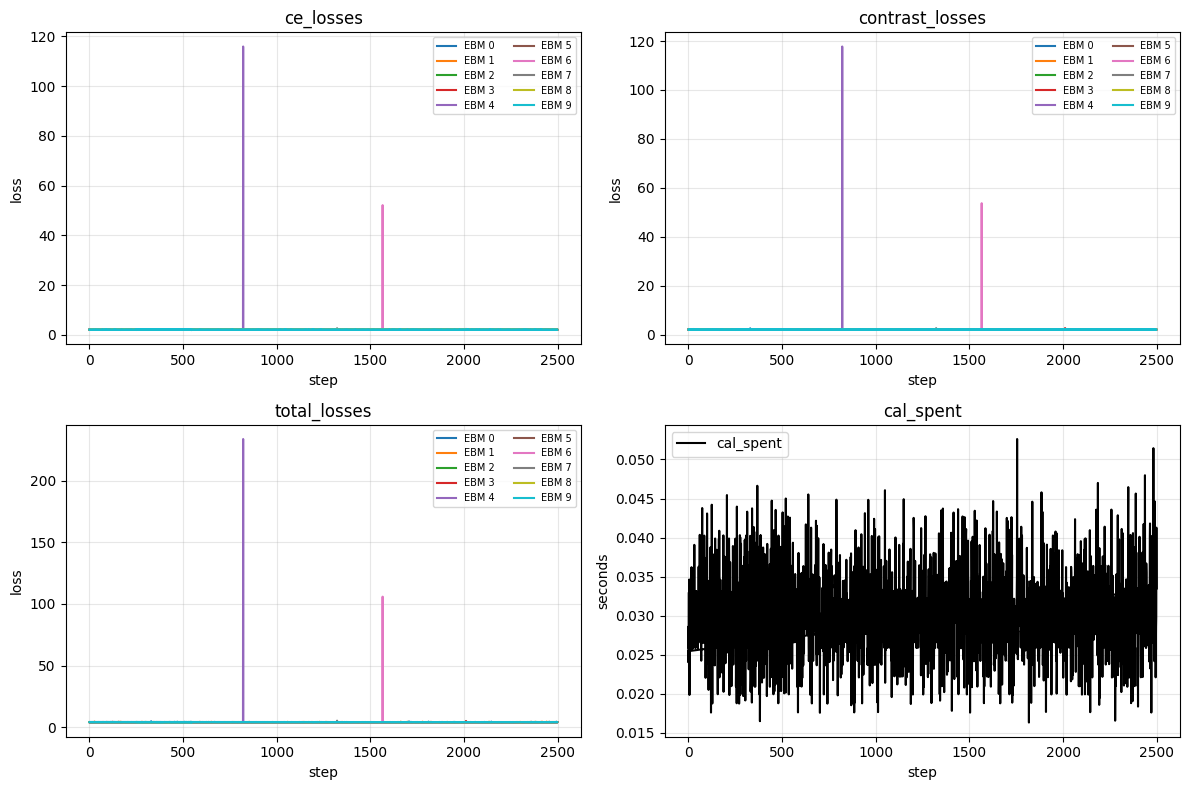

In [22]:
#_________________________
task_name = 'sudoku'
model_arc = 'bert'
param_type = 'fast'
model_scale = 'tiny'
#_________________________
print(f'cwd: {os.getcwd()}')

log_file = f'./matplotlib/{task_name}_{param_type}_{model_arc}_{model_scale}_10k_loss.jsonl'

# ---------- 1. 读数据 ----------
records = []
with open(log_file) as f:
    for line in f:
        records.append(json.loads(line))

steps = [r['i'] for r in records]          # x 轴：step 0,1,2...

# ---------- 2. 准备 4 个子图 ----------
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()                     # 拉平成 1-D 列表
titles = ['ce_losses', 'contrast_losses', 'total_losses', 'cal_spent']

for ax, key in zip(axes, titles):
    # if key != 'ce_losses':
    #     continue
    if key == 'cal_spent':                # 单值
        y = [r[key] for r in records]
        ax.plot(steps, y, label='cal_spent', color='k')
    else:                                 # 8 条曲线
        for k in map(str, range(10)):      # specify your range here! (K)
            y = [r[key][k] for r in records]
            ax.plot(steps, y, label=f'EBM {k}')
    ax.set_title(key)
    ax.set_xlabel('step')
    ax.set_ylabel('loss' if key != 'cal_spent' else 'seconds')
    ax.grid(alpha=0.3)
    if key != 'cal_spent':                # 8 条曲线图例放小一点
        ax.legend(fontsize=7, ncol=2)
    else:
        ax.legend()

plt.tight_layout()
plt.show()

In [6]:
'''
Playground
'''
import numpy as np
def unmasking_schedule(k, n):
    """
    k: 总步数
    n: 待揭开位置总数
    返回: list[k] 每一步**新增**的揭开个数
    """
    # 1. 计算每步累计比例（0→1）
    cum_ratio = 0.5 * (1 - np.cos(np.linspace(0, np.pi, k)))
    # 2. 换算成累计个数
    cum_cnt = np.clip(np.round(cum_ratio * n), 1, n-1).astype(int)
    # 3. 差分得到每步新增
    step_cnt  = np.diff(np.concatenate([[0], cum_cnt]))
    return step_cnt.tolist()

In [7]:
unmasking_schedule(k=10, n=92)

[1, 2, 8, 12, 15, 16, 15, 12, 8, 2]